<a href="https://colab.research.google.com/github/dimasjanotama/data-science-2026/blob/main/Pertemuan7_%5BDimas_Janotama%5D_%5B240401010264%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Dimas Prih P J<br>
NIM : 240401010264<br>
Kelas : IF403<br>

#1. Generate & Eksplorasi Dataset

--- Berikut shape dari data sintetis tersebut ---
Shape: (300, 4)
Dari hasil tersebut dapat diketahui data sintetis tersebut memiliki 300 baris dan 4 kolom


--- Berikut hasil EDA singkat dari data sintetis tersebut ---
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


--- Berikut grafik scatterplot untuk variabel pengalaman dengan Gaji per Kota ---



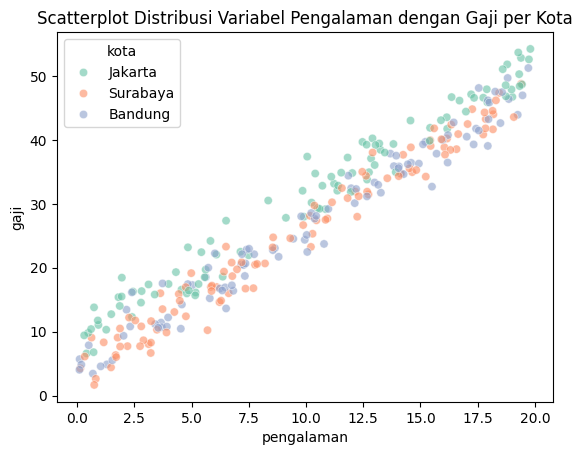

In [38]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Generate dataset sintetis
np.random.seed(42); n = 300
pengalaman = np.random.uniform(0, 20, n)
edu        = np.random.choice([0, 1, 2], n)  # SMA=0, D3=1, S1=2
kota       = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
        + np.where(kota=='Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))
df = pd.DataFrame({'pengalaman':pengalaman, 'edu':edu,
                   'kota':kota, 'gaji':gaji})
# EDA singkat
print('--- Berikut shape dari data sintetis tersebut ---')
print('Shape:', df.shape)
print('Dari hasil tersebut dapat diketahui data sintetis tersebut memiliki 300 baris dan 4 kolom\n\n')

print('--- Berikut hasil EDA singkat dari data sintetis tersebut ---')
print(df.describe().round(2))

# Scatter: Pengalaman dengan Gaji per Kota
print('\n\n--- Berikut grafik scatterplot untuk variabel pengalaman dengan Gaji per Kota ---\n')
sns.scatterplot(data=df, x='pengalaman', y='gaji',
                hue='kota', palette='Set2', alpha=0.6)
plt.title('Scatterplot Distribusi Variabel Pengalaman dengan Gaji per Kota')
plt.show()

#2. Preprocessing

In [39]:
# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'],
                    drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Data Training: {X_train.shape[0]} baris')
print(f'Data Testing: {X_test.shape[0]} baris')

# StandardScaler — fit pada training set saja
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Data Training: 240 baris
Data Testing: 60 baris


#3. Latih Model & Tampilkan Koefisien

In [40]:
model = LinearRegression()
model.fit(X_train_s, y_train)

# Tampilkan koefisien
print(f'β0 (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

β0 (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


Interpretasi Data :

- Variabel pengalaman memiliki pengaruh paling kuat (13.042). Artinya, setiap peningkatan satu satuan unit pada pengalaman misalnya 1 tahun tambahan, diprediksi akan meningkatkan nilai Y sebesar 13.042, dengan asumsi variabel lain tetap konstan.

- Untuk Variabel edu (1.188) artinya setiap peningkatan satu unit pada tingkat pendidikan (jenjang pendidikan lebih tinggi 1 tingkat), diprediksi akan meningkatkan nilai Y sebesar 1.188, dengan asumsi variabel lain tetap konstan.

- Jika pekerja tinggal di Jakarta, maka nilai Y diprediksi akan bertambah 1.837

- Jika pekerja tinggal di Surabaya, maka nilai Y diprediksi akan berkurang sebesar 0.292. Koefisien negatif menunjukkan bahwa faktor ini memiliki korelasi yang menurunkan nilai prediksi.

#4. Evaluasi Model

In [41]:
from sklearn.metrics import (mean_absolute_error,
    mean_squared_error, r2_score)

y_pred = model.predict(X_test_s)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R2   = {r2:.4f}  ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

# Interpretasikan dalam Markdown sel berikutnya:
# - Berapa rata-rata kesalahan prediksi dalam rupiah?
# - Apakah R2 cukup baik untuk kasus ini?
# - Apakah ada indikasi outlier?

=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R2   = 0.9740  (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


Interpretasi Data

- Rata-rata kesalahan prediksi ditunjukkan oleh MAE adalah sebesar 1.649 juta rupiah. Artinya, secara rata-rata model prediksi ini bisa meleset sebesar 1,65 juta rupiah dari nilai aktual.
- Nilai R2 sangat baik (0.9740). Skor R2 yang mendekati 1.0 menunjukkan bahwa model memiliki kemampuan prediksi yang baik.
- Selisih antara RMSE dan MAE adalah sebesar 0.474 atau 28% dari nilai MAE, menunjukkan ada indikasi keberadaan outlier yang cukup signifikan.

#5. Visualisasi & Interpretasi

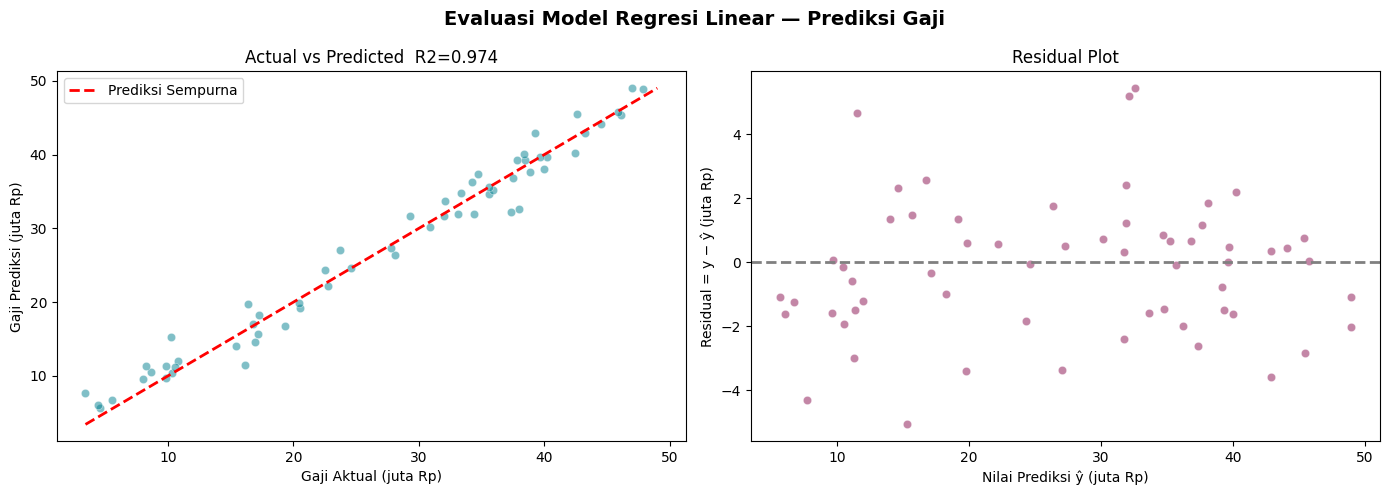

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5,
                color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2,
             label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted  R2={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5,
                color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')
plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()
# Cara membaca Residual Plot:
# ✅ Baik: titik tersebar ACAK di sekitar garis y=0
# ❌ Masalah: ada pola (kurva, corong) → asumsi linearitas dilanggar

Interpretasi Data

Actual vs Predicted Plot:
- What : Titik-titik data tersebar rapat di sepanjang garis prediksi sempurna.
- So What : Titik yang rapat secara visual mengonfirmasi nilai R2 = 0.974 yang diperoleh sebelumnya, yaitu model ini sangat reliabel dalam memprediksi gaji karena hampir tidak ada deviasi besar dari tren linier yang diharapkan.
- Now What : Model ini bisa dibilang akurat dalam memprediksi sehingga dapat dipakai / dikembangkan modelnya lebih lanjut.

Residual Plot:
- What : Titik tersebar secara acak di sekitar garis y=0. Ini adalah tanda  bahwa model telah menangkap pola data dengan baik. Terlihat ada beberapa titik yang berada cukup jauh dari garis nol, yaitu di sekitar nilai prediksi 15 dan nilai prediksi 32-33.
- So What : Titik-titik tersebut tidak membentuk pola tertentu seperti bentuk kurva atau corong, ini mengindikasikan bahwa asumsi linearitas terpenuhi.
- Now What : Secara umum model ini sudah mampu menangkap data dengan baik, namun perlu ada identifikasi data yang menghasilkan titik yang jauh dari garis nol diatas. Apakah mereka memiliki karakteristik khusus, misal apakah memang itu terjadi untuk case jabatan yang unik.

#Yang Saya Pelajari
Pada pertemuan ini, saya mempelajari alur pengembangan model regresi linear, mulai dari menghasilkan serta mengeksplorasi dataset hingga melakukan preprocessing agar data siap diolah. Saya belajar cara melatih model, serta melakukan evaluasi menggunakan metrik seperti MAE, RMSE, R2. Saya juga belajar memvisualisasikan hasil model melalui plot Actual vs Predicted serta Residual Plot.